# Cybersecurity Mean-Field Control Benchmark

Reference: Meunier, Pham & Reisinger, discrete-space benchmarks, Section "Cybersecurity Example" (`files/reference/discrete_benchmarks.tex`), adapted from Kolokoltsov & Bensoussan's mean-field game of botnet defense via Carmona et al.'s mean-field control formulation.

**Model.** A large population of computers, each in one of four states $\mathcal X=\{\mathrm{DI},\mathrm{DS},\mathrm{UI},\mathrm{US}\}$ (defended/undefended $\times$ infected/susceptible). Action space $\mathcal A=\{0,1\}$: $0$ keeps the current protection level, $1$ switches it (rate $\lambda_\mathrm{sw}$). Infection spreads at endogenous rates depending on the population's own infected fractions:
$$\iota_D(\mu)=v_H q_\mathrm{inf}^D+\beta_{DD}\mu(\mathrm{DI})+\beta_{UD}\mu(\mathrm{UI}), \qquad \iota_U(\mu)=v_H q_\mathrm{inf}^U+\beta_{UU}\mu(\mathrm{UI})+\beta_{DU}\mu(\mathrm{DI}).$$
The continuous-time generator $Q^{\mu,a}$ this induces is discretized *exactly* via $P_{\Delta t}^{\mu,a}=\exp(\Delta t\,Q^{\mu,a})$ (`mfc.environments.cybersecurity.CyberSecurity.transition_probs`) — unlike two-state, the transition kernel itself depends on the population law.

A computer incurs cost $f(x)=k_D\mathbf 1_{\{x\in\{\mathrm{DI,DS}\}\}}+k_I\mathbf 1_{\{x\in\{\mathrm{DI,UI}\}\}}$; running and terminal rewards are both $-\Delta t\,f(x)$, discounted by $\gamma=0.5$.

**Policy.** A population-dependent 2-hidden-layer MLP (width 32, $\tanh$), taking $(t,\mu)$ and outputting a $4\times2$ logit matrix, row-softmaxed — unlike two-state's stationary lookup-table policy (`CyberSecurity.policy_probs`; all parameters packed into one flat vector so it drops into the same `action_probs_fn` machinery unchanged).

**Training/validation asymmetry.** Training uses a short horizon $T_\mathrm{train}=3$ (limits sensitivity-estimator error accumulation) with $\mu_0\sim\mathrm{Dirichlet}(1,1,1,1)$ resampled every iteration; validation freezes the policy and evaluates over a much longer $T_\mathrm{val}=50$ from the uniform law $\mu_0^\mathrm{val}=(\tfrac14,\tfrac14,\tfrac14,\tfrac14)$ — deliberately feeding the policy $t$ values it never saw in training, per the reference's own protocol.

Unlike two-state, there is no known closed-form optimal policy here, so this notebook has no "vs. optimal" diagnostics (policy error, theta bias vs. ground truth); the reference itself validates qualitatively against a separately reported mean-field $Q$-learning benchmark (Carmona et al.), which is not digitized in this repo.

In [1]:
import sys
import time
from pathlib import Path

_notebook_start = time.perf_counter()

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
for path in (SRC, ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import torch

torch.set_default_dtype(torch.float64)
torch.set_default_device("cuda" if torch.cuda.is_available() else "cpu")

from configs.cybersecurity import MID
from mfc.environments.cybersecurity import DI, DS, UI, US, CyberSecurity, CyberSecurityConfig
from mfc.plotting import diagnostics as viz
from scripts.train import run_all
from scripts.test import (
    generalization_eval,
    gradient_diagnostics,
    intervention_probability,
    load_runs,
    objective_gap,
    perturbation_coverage,
    rollout,
    state_distribution,
)

## Configuration and budget

This notebook demonstrates the **mid** run tier from `configs/cybersecurity.py`: one seed, the reference's training horizon $T_\mathrm{train}=3$ and validation horizon $T_\mathrm{val}=50$, a reduced training length (5000 iterations, vs. the reference's own 20000 — kept here for wall-clock time; see `main` for the reference's full length and 5 seeds), the exact population flow, and the equal-parameters budget ($B=200$, $n_\mathrm{aux}=1$ for every $\lambda$, matching the reference's own unadjusted allocation for this benchmark). Run `scripts/train.py --config main` separately for the full main-tier sweep.

In [2]:
cfg = MID
print(f"algorithms:    {cfg.algorithms}")
print(f"lambdas:       {cfg.lambdas}  (simplex perturbation scale)")
print(f"epsilon:       {cfg.epsilon}  (logit perturbation scale, fixed per context.md)")
print(f"T_train={cfg.horizons[0]}, T_val={cfg.T_val}")
print(f"seeds:         {cfg.seeds}")
print(f"B={cfg.B}, n_aux={cfg.n_aux}, sigma={cfg.sigma}, lr={cfg.lr}, n_train={cfg.n_train}")
print(f"mu0 ~ Dirichlet(1,1,1,1) during training; validation mu0={cfg.mu0_val}")
print(f"gamma={CyberSecurityConfig().gamma}  (discount, an environment constant)")

algorithms:    ('simplex', 'mfreinforce', 'reinforce')
lambdas:       (0.1, 0.2, 0.4, 0.8)  (simplex perturbation scale)
epsilon:       1.0  (logit perturbation scale, fixed per context.md)
T_train=3, T_val=50
seeds:         (0,)
B=200, n_aux=1, sigma=1.0, lr=0.001, n_train=5000
mu0 ~ Dirichlet(1,1,1,1) during training; validation mu0=(0.25, 0.25, 0.25, 0.25)
gamma=0.5  (discount, an environment constant)


## Train (or load cached results)

Loads every saved run under `runs/cybersecurity/mid/` for all three algorithms; trains first if none exist yet (`scripts/train.py`'s own entry point — safe to re-run, results are cached to disk). Unlike two-state, `reinforce` and `mfreinforce` also have no lambda to sweep, so each contributes a single run per seed.

In [3]:
env = CyberSecurity()
runs_dir = ROOT / "runs" / "cybersecurity" / "mid"

runs = []
for alg in cfg.algorithms:
    if not list(runs_dir.glob(f"{alg}_*_seed*.pt")):
        run_all("cybersecurity", alg, "mid")
    runs += load_runs("cybersecurity", alg, "mid")

total_train_seconds = sum(r["elapsed_seconds"] for r in runs)
print(f"{len(runs)} runs loaded; total training compute time: {total_train_seconds:.1f}s ({total_train_seconds / 60:.1f} min)")
for r in sorted(runs, key=lambda r: (r["alg"], r["lam"] if r["lam"] is not None else -1)):
    tag = f"lambda={r['lam']}" if r["lam"] is not None else "(fixed epsilon)"
    print(f"  {r['alg']:<11} {tag:<16} seed={r['seed']}  elapsed={r['elapsed_seconds']:.1f}s  final validation J={r['validation_J'][-1].item():.4f}")

[cybersecurity/mid] mfreinforce_equal_parameters_exact_T3_seed0 ... 

KeyboardInterrupt: 

## Evolution of the validation reward

The exact validation objective $J_{T_\mathrm{val}}(\theta_m;\mu_0^\mathrm{val})$ every 10 training iterations, one line per simplex $\lambda$ plus reinforce and mfreinforce (each contributing a single line, since neither sweeps a perturbation scale — `plot_validation_curve` groups by `(alg, lam)` precisely so these don't collide into one averaged line).

/home/adonis/Internship/MFC_RL/.venv/lib/python3.12/site-packages/torch/utils/_device.py:122: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1879.)
  return func(*args, **kwargs)


Text(0.0, 1.0, 'Validation objective during training')

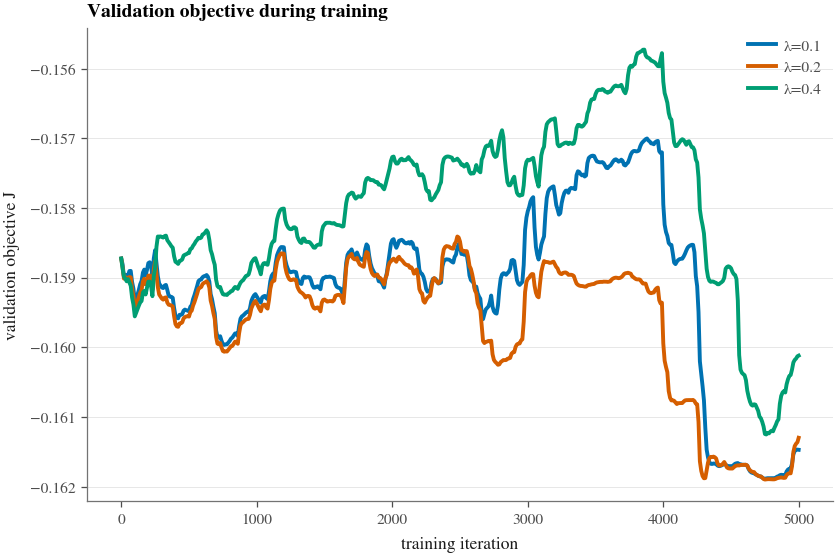

In [4]:
fig, ax = viz.plot_validation_curve(runs)
ax.set_title("Validation objective during training", loc="left")

## State distribution over time (validation horizon)

The learned policy's population flow $\mu_t^\theta$ from $\mu_0^\mathrm{val}$ over $T_\mathrm{val}=50$ steps, shown for $\lambda=0.2$ — note the policy is fed $t$ values (up to 49) well beyond the $t\in\{0,1,2\}$ it ever saw during training, per the reference's own validation protocol.

Text(0.0, 1.0, 'State distribution over T_val=50 (lambda=0.2)')

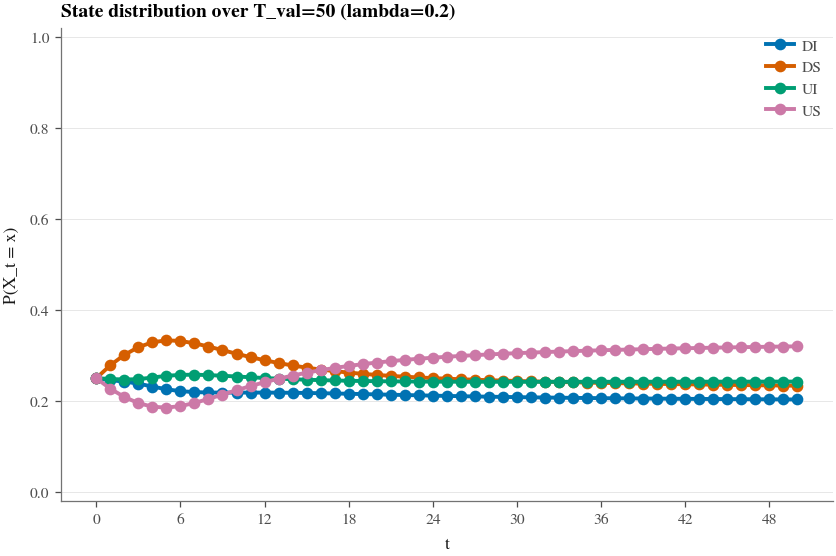

In [5]:
by_lambda = {r["lam"]: r for r in runs if r["alg"] == "simplex"}  # mid has one seed per lambda
theta_02 = by_lambda[0.2]["theta_final"]
mu0_val = torch.tensor(cfg.mu0_val, dtype=env.dtype, device=env.device)

mu_flow = state_distribution(env, env.policy_probs, theta_02, mu0_val, cfg.T_val)
fig, ax = viz.plot_state_distribution(mu_flow, state_labels=["DI", "DS", "UI", "US"])
ax.set_title(f"State distribution over T_val={cfg.T_val} (lambda=0.2)", loc="left")

## Aggregate infected/defended fractions and intervention probability

Beyond the per-state flow: the aggregate infected fraction $I_t=\mu_t(\mathrm{DI})+\mu_t(\mathrm{UI})$, defended fraction $D_t=\mu_t(\mathrm{DI})+\mu_t(\mathrm{DS})$, and the population-averaged intervention probability $A_t=\sum_x\mu_t(x)\pi_t(1\mid x,\mu_t)$ (reference "Evaluation criteria").

Text(0.0, 1.0, 'Aggregate population diagnostics (lambda=0.2)')

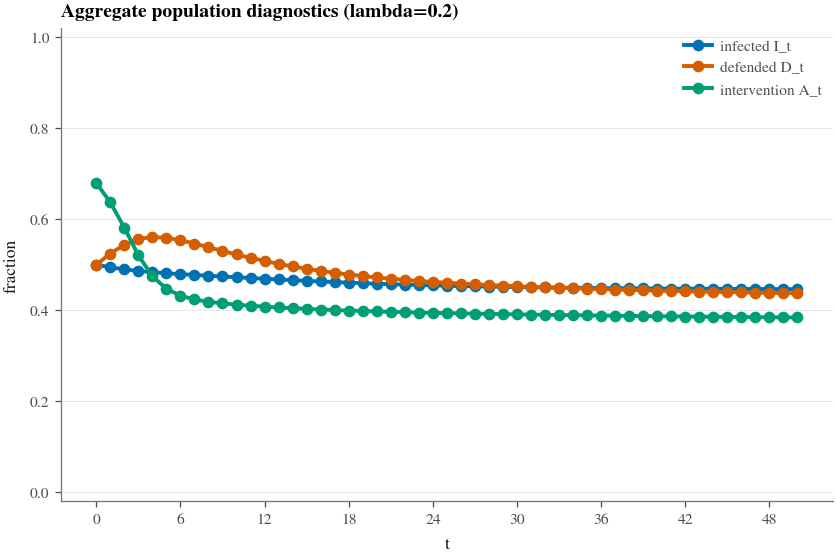

In [6]:
infected, defended = env.aggregate_fractions(mu_flow)
intervention = intervention_probability(env, env.policy_probs, theta_02, mu_flow)

fig, ax = viz.plot_population_fractions({"infected I_t": infected, "defended D_t": defended, "intervention A_t": intervention})
ax.set_title("Aggregate population diagnostics (lambda=0.2)", loc="left")

## $J^\lambda$ vs $J$ and gradient bias/variance

Two diagnostics across the $\lambda$ sweep, all at each $\lambda$'s own learned $\theta$, evaluated at $T_\mathrm{train}$ (where the simplex machinery — and hence $J^\lambda$ and the plug-in gradient — is actually defined) rather than $T_\mathrm{val}$, both discounted by $\gamma=0.5$ to match the training objective:
- $J^\lambda$ (Monte Carlo, perturbed) vs $J$ (exact) — the perturbation's effect on the objective itself.
- Empirical bias/variance of the simplex plug-in gradient estimator vs. the exact (autograd) gradient — summarized as $\|\text{bias}\|$/$\|\text{std}\|$ over the full 1512-dimensional MLP parameter vector (a per-component view, as used for two-state's 2-dimensional $\theta$, isn't legible at this dimension).

Text(0.0, 1.0, 'Simplex gradient estimator: bias/std norms vs lambda')

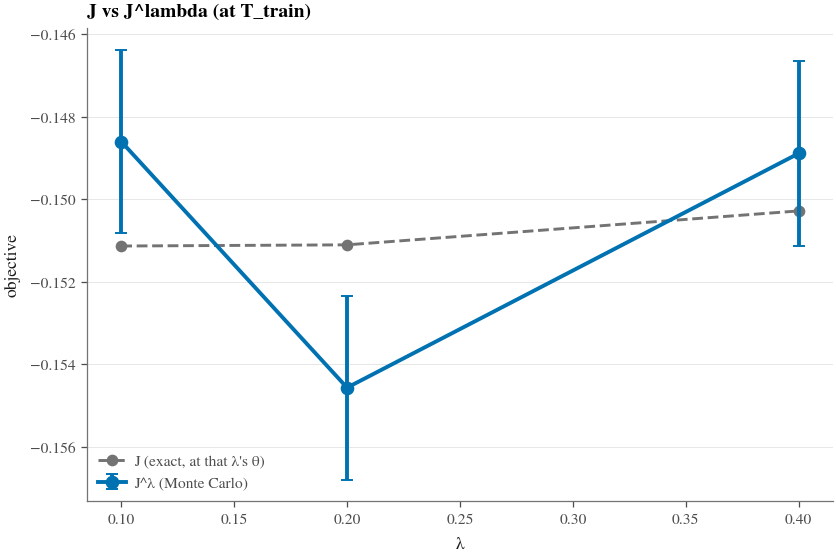

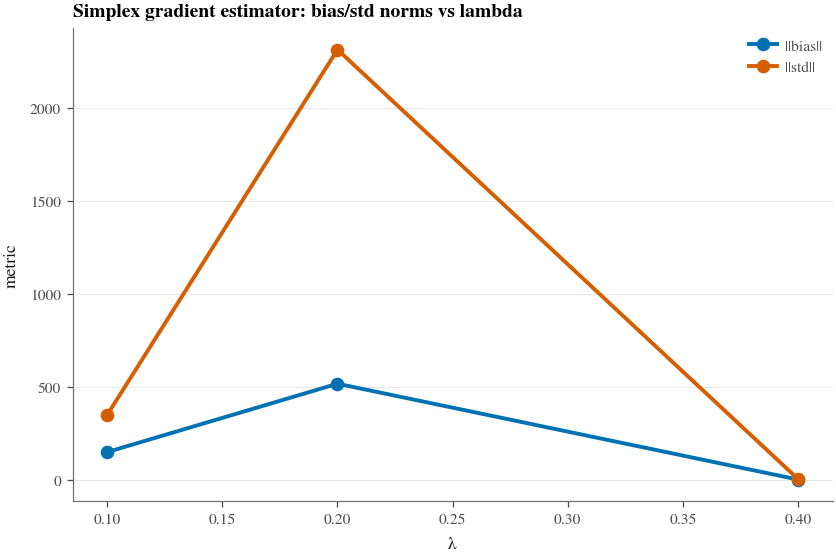

In [7]:
gamma = env.config.gamma

gaps, grad_diag = {}, {}
for lam, r in by_lambda.items():
    theta = r["theta_final"]
    gaps[lam] = objective_gap(env, env.policy_probs, theta, mu0_val, cfg.horizons[0], lam=lam, sigma=cfg.sigma, n_samples=2000, gamma=gamma)
    grad_diag[lam] = gradient_diagnostics(
        env, env.policy_probs, theta, mu0_val, cfg.horizons[0],
        lam=lam, n_aux=cfg.n_aux, B=cfg.B, sigma=cfg.sigma, reps=20, gamma=gamma,
    )

fig, ax = viz.plot_objective_gap(gaps)
ax.set_title("J vs J^lambda (at T_train)", loc="left")

bias_norm = {lam: grad_diag[lam]["bias"].norm().item() for lam in grad_diag}
std_norm = {lam: grad_diag[lam]["std"].norm().item() for lam in grad_diag}
fig, ax = viz.plot_horizon_scaling(bias_norm, xlabel="\u03bb", ylabel="norm over 1512 MLP parameters", label="||bias||", integer_xaxis=False)
viz.plot_horizon_scaling(std_norm, xlabel="\u03bb", label="||std||", color_index=1, integer_xaxis=False, ax=ax)
ax.set_title("Simplex gradient estimator: bias/std norms vs lambda", loc="left")

## Simplex-perturbation coverage: $d_{TV}(M^\lambda,\mu)\le\lambda$

Checked here (as for two-state) by direct sampling at a few representative population laws, now $N=4$-dimensional: the validation law, an extreme corner (all computers defended+infected), and a point from the learned flow itself.

bound holds for all sampled mu (as guaranteed by the theorem).


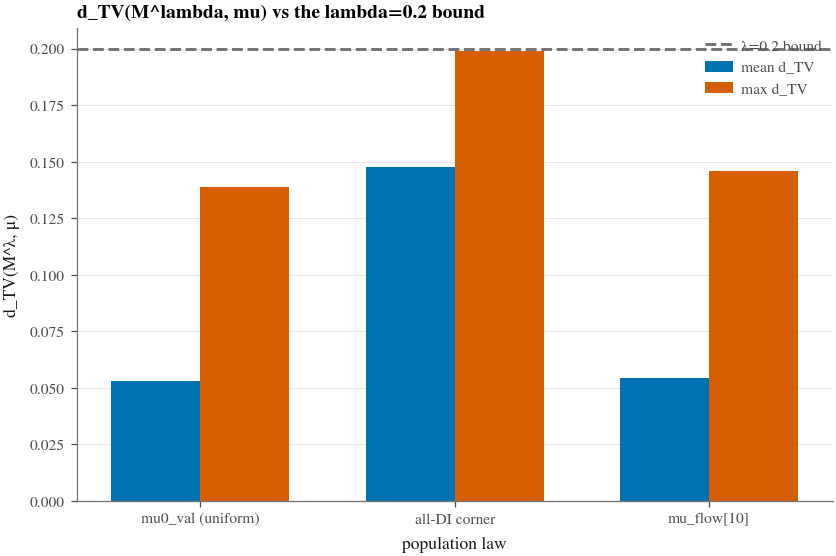

In [8]:
all_DI = torch.tensor([1.0, 0.0, 0.0, 0.0], dtype=env.dtype, device=env.device)
coverage = perturbation_coverage(torch.stack([mu0_val, all_DI, mu_flow[10]]), lam=0.2, sigma=cfg.sigma, n_samples=5000)
fig, ax = viz.plot_perturbation_coverage(coverage, lam=0.2, mu_labels=["mu0_val (uniform)", "all-DI corner", "mu_flow[10]"])
ax.set_title("d_TV(M^lambda, mu) vs the lambda=0.2 bound", loc="left")

for r in coverage:
    assert r["within_bound"], "the perturbation theorem's bound should never be violated"
print("bound holds for all sampled mu (as guaranteed by the theorem).")

## Sample trajectory under the learned policy

One sampled state trajectory ($\lambda=0.2$) from $\mu_0^\mathrm{val}$, over the training horizon $T_\mathrm{train}=3$ (states 0-3 correspond to DI, DS, UI, US). There is no known optimal policy to compare against here (unlike two-state).

Text(0.0, 1.0, 'Sample trajectory (lambda=0.2)')

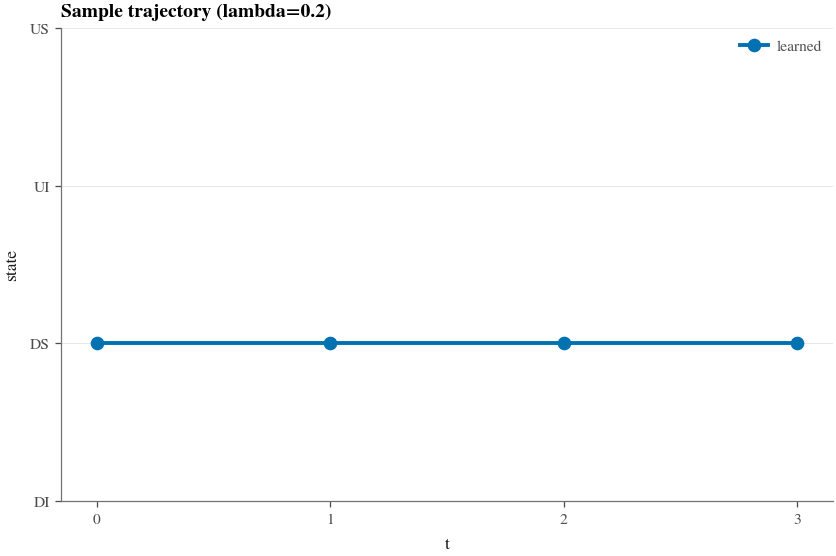

In [9]:
learned_traj = rollout(env, env.policy_probs, theta_02, mu0_val, T=cfg.horizons[0], generator=torch.Generator(device=env.device).manual_seed(0))
fig, ax = viz.plot_trajectories(learned_traj)
ax.set_yticks([DI, DS, UI, US])
ax.set_yticklabels(["DI", "DS", "UI", "US"])
ax.set_title("Sample trajectory (lambda=0.2)", loc="left")

## Generalization without retraining

Evaluating the $\lambda=0.2$ learned $\theta$ exactly (no retraining) under different initial laws, a longer horizon, and model misspecification (shifted infection rates / switching rate).

Text(0.0, 1.0, 'J under different scenarios (theta fixed, no retraining)')

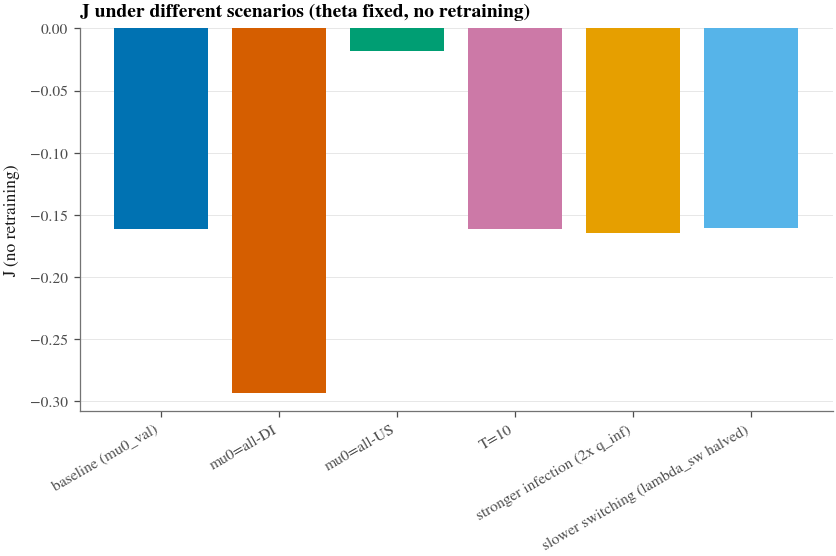

In [10]:
all_US = torch.tensor([0.0, 0.0, 0.0, 1.0], dtype=env.dtype, device=env.device)
scenarios = [
    {"name": "baseline (mu0_val)"},
    {"name": "mu0=all-DI", "mu0": all_DI},
    {"name": "mu0=all-US", "mu0": all_US},
    {"name": "T=10", "T": 10},
    {"name": "stronger infection (2x q_inf)", "env": CyberSecurity(CyberSecurityConfig(q_inf_D=0.8, q_inf_U=0.6))},
    {"name": "slower switching (lambda_sw halved)", "env": CyberSecurity(CyberSecurityConfig(lambda_sw=0.4))},
]
gen_results = generalization_eval(env, env.policy_probs, theta_02, mu0_val, cfg.T_val, scenarios, gamma=gamma)
fig, ax = viz.plot_generalization(gen_results)
ax.set_title("J under different scenarios (theta fixed, no retraining)", loc="left")

## Comparing the three algorithms

At `mid`'s single seed, final validation objective for each algorithm — simplex at its best-performing $\lambda$ (from the validation curve above), reinforce (`mfc.algorithms.reinforce`, which omits the population-sensitivity correction $Q_t(D_t)$ entirely — see its module docstring), and mfreinforce (Meunier's own logit-perturbed estimator, fixed $\varepsilon$). A single seed can't separate genuine differences from noise; `main`'s 5 seeds are needed for a real comparison, as for two-state's own "missing mean-field term" section.

In [11]:
by_alg = {}
for r in runs:
    by_alg.setdefault(r["alg"], []).append(r)

best_simplex = max(by_alg["simplex"], key=lambda r: r["validation_J"][-1].item())
print(f"best simplex lambda: {best_simplex['lam']}")
for alg in cfg.algorithms:
    r = best_simplex if alg == "simplex" else by_alg[alg][0]
    print(f"  {alg:<11} final validation J = {r['validation_J'][-1].item():.4f}")

best simplex lambda: 0.4
  simplex     final validation J = -0.1601


KeyError: 'mfreinforce'

## Summary

Total notebook runtime (including any training performed in this run):

In [ ]:
print(f"total notebook runtime: {time.perf_counter() - _notebook_start:.1f}s")